In [1]:
%load_ext autoreload
%autoreload 2
import sys
from matplotlib.lines import Line2D
from csbdeep.utils import normalize

sys.path.append("..")
from src import *

Cupy Available= 1


In [3]:
dataset = "synthetic"
variant = 150
methods = ["cellpose", "stardist", "cellsam"]
datas = ["Noisy", "DeepCAD-RT", "Freq2Clean"]
meta = DATASETS[dataset]

In [5]:
df = pd.DataFrame(columns=["data", "method", "iou"])
for method in ["cellpose"]:
    ious_x = pd.read_json(f"{method}_results/{dataset}/x/ious.json", typ="series")
    ious_dcad = pd.read_json(f"{method}_results/{dataset}/deepcad_{variant}/ious.json", typ="series")
    ious_f2c = pd.read_json(f"{method}_results/{dataset}/fft_{variant}/ious.json", typ="series")
    for data, ious in zip(datas, [ious_x, ious_dcad, ious_f2c]):
        for iou in ious:
            df.loc[len(df)] = (data, method, iou)

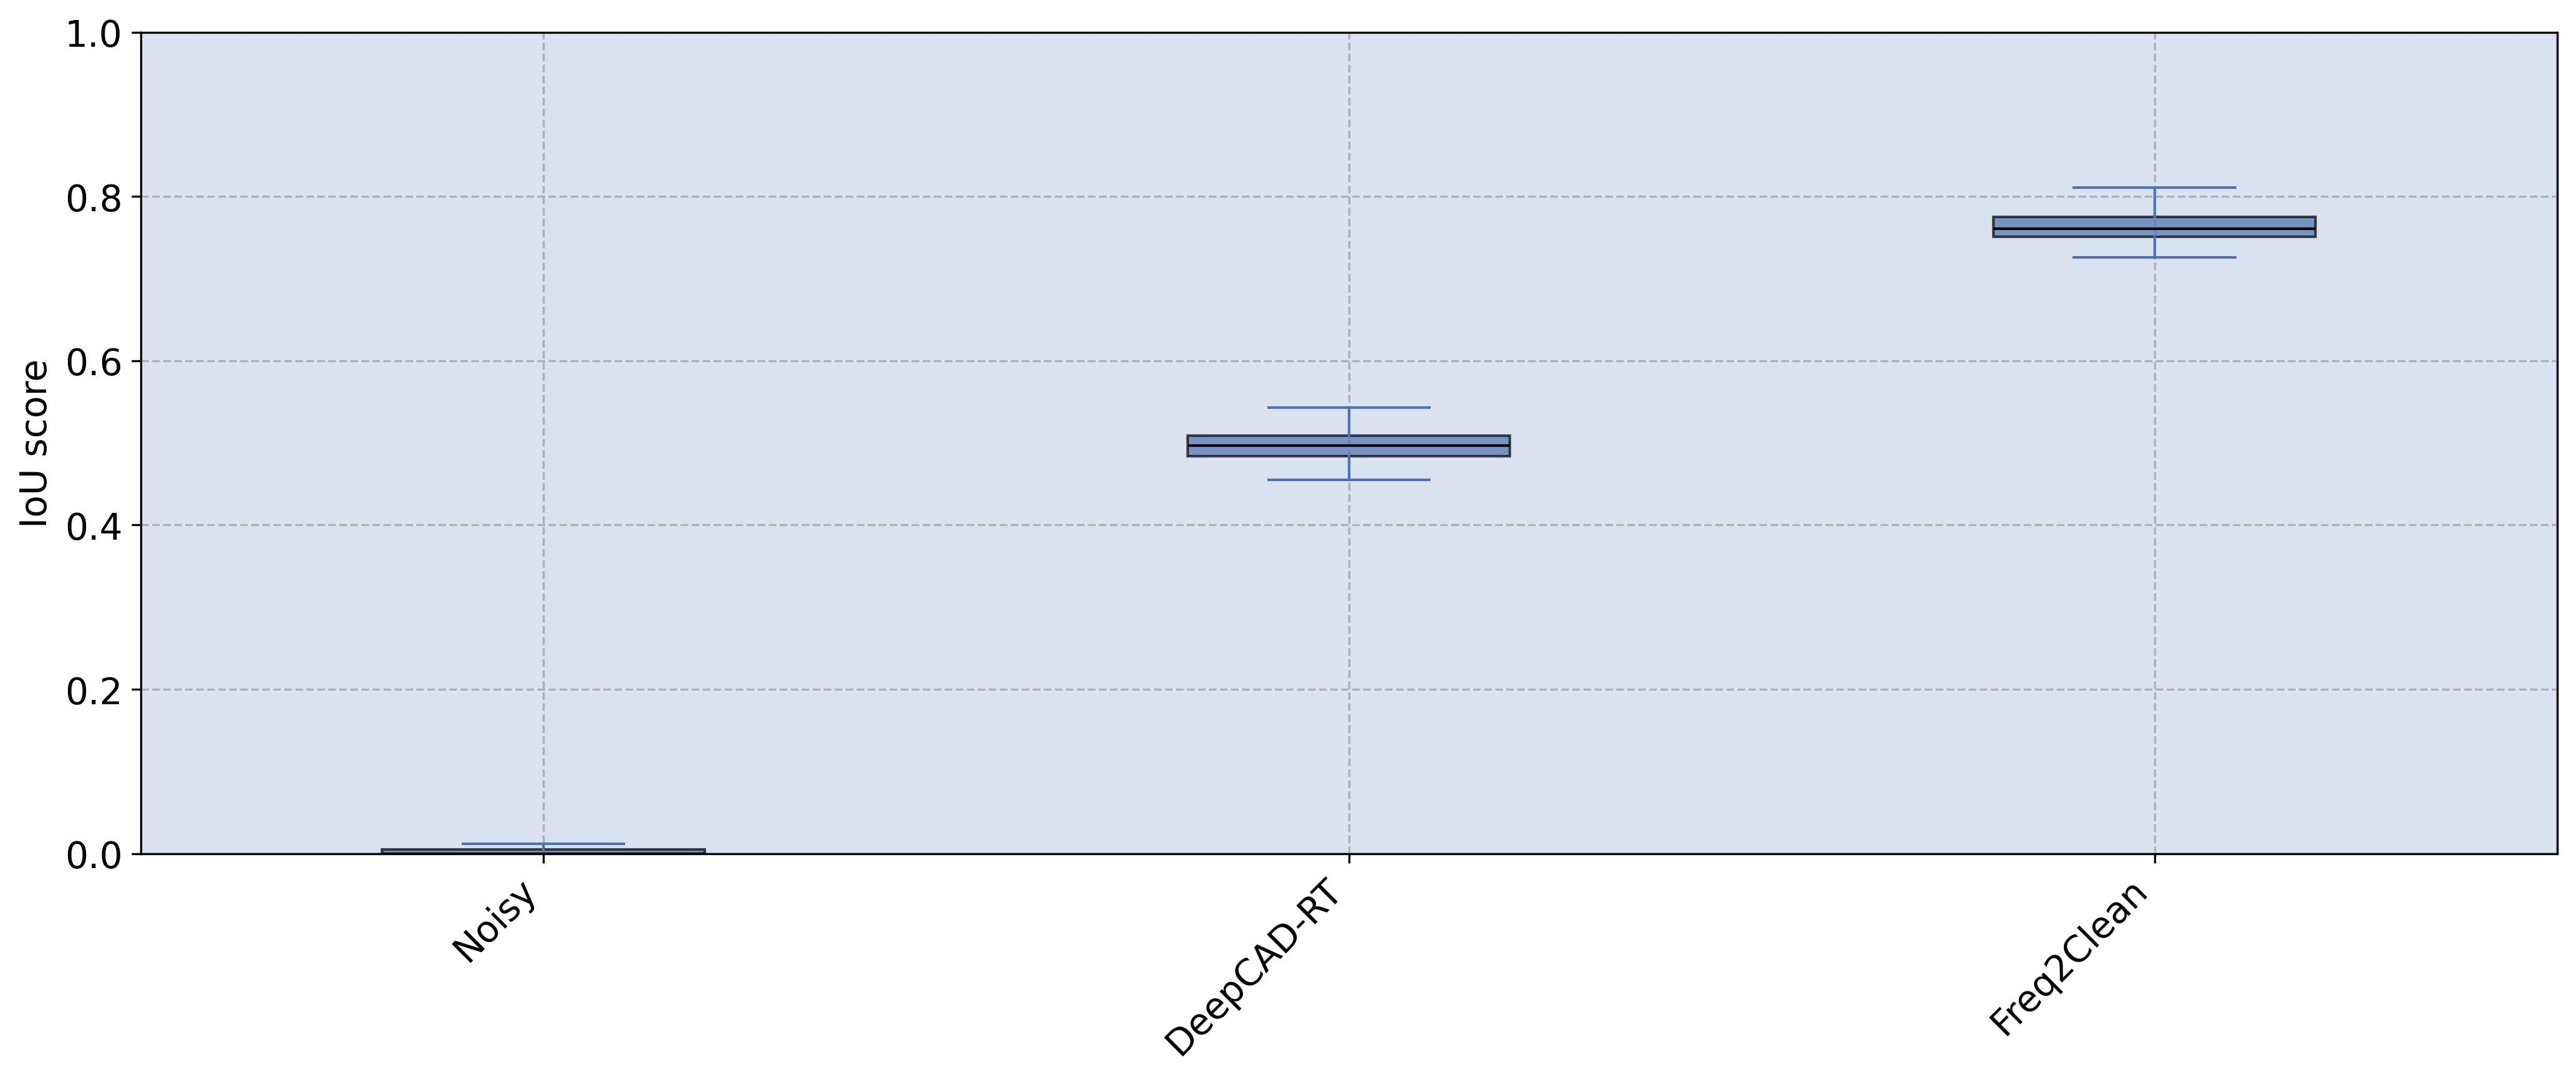

In [ ]:
def violin(method,color, width=0.35):
    def plot_boxplots(ax, positions, values, label, color):
        bp = ax.boxplot(
            values,
            positions=positions,
            widths=0.4,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.7),
            medianprops=dict(color="black"),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
            flierprops=dict(markeredgecolor="#00000000"),
        )
        return bp

    _, ax = plt.subplots(figsize=(14, 6), dpi=300)
    data = [df[(df["method"] == method) & (df["data"] == m)]["iou"].values for m in datas]
    plot_boxplots(ax, np.arange(len(datas)), data, "Cellpose", "#4C72B0")
    ax.axvspan(-0.5, len(datas) - 0.5, color=color, alpha=0.2)
    # ax.set_xticks(pos)
    ax.set_ylim((0, 1))
    ax.set_xticklabels(datas, rotation=45, ha="right")
    ax.set_ylabel("IoU score")
    plt.tight_layout()
    plt.show()
    
violin("cellpose", "#4C72B0")